# Huấn Luyện Mô Hình Dự Đoán Thất Bại Thử Nghiệm Lâm Sàng Ung Thư

**Notebook 05: Huấn luyện và Đánh giá Mô hình**

**Câu hỏi nghiên cứu:** Liệu có thể dự báo sớm nguy cơ thất bại của thử nghiệm lâm sàng ung thư chỉ dựa trên đặc điểm thiết kế ban đầu?

## A. Question Formulation

### 1. Câu hỏi nghiên cứu

**Câu hỏi:** Liệu chúng ta có thể dự báo sớm nguy cơ thất bại của các thử nghiệm lâm sàng ung thư chỉ dựa trên các đặc điểm thiết kế ban đầu (pre-trial features) hay không? Và đâu là những yếu tố quyết định dẫn đến dự báo đó?

**Mục tiêu:** Xây dựng mô hình phân loại nhị phân (Binary Classification) để dự đoán kết quả thử nghiệm lâm sàng ung thư dựa trên 34 đặc trưng pre-trial, với biến mục tiêu là `label_binary` (1 = Thành công/COMPLETED, 0 = Thất bại/TERMINATED hoặc WITHDRAWN).

### 2. Động cơ nghiên cứu

Thử nghiệm lâm sàng ung thư có tỷ lệ thất bại rất cao, dao động từ 70% đến 90%, với chi phí trung bình từ 50 đến 100 triệu USD cho mỗi thử nghiệm. Việc dự đoán sớm nguy cơ thất bại sẽ giúp các công ty dược phẩm và nhà nghiên cứu đưa ra quyết định Go/No-Go kịp thời, từ đó tiết kiệm đáng kể nguồn lực tài chính và nhân lực.

### 3. Ý nghĩa thực tiễn

Mô hình dự đoán thất bại thử nghiệm lâm sàng có thể được ứng dụng như một công cụ sàng lọc ban đầu (screening tool) trong quy trình đánh giá các thử nghiệm mới. Kết quả từ mô hình sẽ hỗ trợ các chuyên gia trong việc ưu tiên nguồn lực cho các thử nghiệm có nguy cơ cao, cải thiện thiết kế nghiên cứu, và tối ưu hóa quy trình phát triển thuốc.

### 4. Phạm vi phân tích

**Dữ liệu đầu vào:** 34 đặc trưng pre-trial (sau khi loại bỏ `has_results` và `enrollment_met` do data leakage)

**Các nhóm đặc trưng chính:**
- TEMPORAL: Thông tin về thời gian (năm bắt đầu, thời lượng nghiên cứu)
- DESIGN: Thiết kế nghiên cứu (randomized, blinded, parallel)
- COMPLEXITY: Độ phức tạp (số interventions, số arms)
- SCALE: Quy mô (enrollment count)
- SPONSOR: Thông tin nhà tài trợ
- INTERVENTION: Loại can thiệp (drug, biological)
- PHASE: Giai đoạn thử nghiệm
- QUALITY: Chất lượng thiết kế (has DMC)

**Metric đánh giá chính:** ROC-AUC (khả năng phân biệt giữa hai lớp)

**Metric phụ:** F1-Score, Precision, Recall, Accuracy

**Chiến lược mô hình hóa:**
- Bước 1: Logistic Regression (Baseline)
- Bước 2: Random Forest (Ensemble Learning)
- Bước 3: XGBoost (Gradient Boosting)
- Bước 4: LightGBM (So sánh)
- Bước 5: Hyperparameter Tuning cho mô hình tốt nhất

**Lưu ý về Data Leakage:** Các features `has_results` và `enrollment_met` đã bị loại bỏ vì chỉ có giá trị sau khi trial kết thúc, đảm bảo mô hình chỉ sử dụng thông tin có sẵn trước khi trial bắt đầu.

## B. Tiền xử lý

### B.1. Import thư viện và cấu hình hệ thống

In [26]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import PredefinedSplit, GridSearchCV

import xgboost as xgb
import lightgbm as lgb

sys.path.insert(0, str(Path.cwd().parent / "src"))
from models.model_trainer import ModelTrainer
from models.model_evaluator import ModelEvaluator

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "model_results"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

LEAKAGE_FEATURES = ['has_results', 'enrollment_met']

print("Cấu hình hệ thống")
print(f"  - Thư mục gốc: {PROJECT_ROOT}")
print(f"  - Thư mục dữ liệu: {DATA_DIR}")
print(f"  - Random seed: {SEED}")
print(f"  - Features bị loại (data leakage): {LEAKAGE_FEATURES}")

Cấu hình hệ thống
  - Thư mục gốc: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction
  - Thư mục dữ liệu: /home/lang-phu-quy/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/data/processed/modeling
  - Random seed: 42
  - Features bị loại (data leakage): ['has_results', 'enrollment_met']


### B.2. Tải dữ liệu Train/Validation/Test

In [27]:
train_df = pd.read_csv(DATA_DIR / "train_features.csv")
val_df = pd.read_csv(DATA_DIR / "val_features.csv")
test_df = pd.read_csv(DATA_DIR / "test_features.csv")

with open(DATA_DIR / "feature_dictionary_updated.json", 'r') as f:
    feature_dict = json.load(f)

print("Kích thước dữ liệu:")
print(f"  - Train set: {train_df.shape[0]:,} mẫu, {train_df.shape[1]} cột")
print(f"  - Validation set: {val_df.shape[0]:,} mẫu, {val_df.shape[1]} cột")
print(f"  - Test set: {test_df.shape[0]:,} mẫu, {test_df.shape[1]} cột")

total = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
print(f"\nTỷ lệ phân chia:")
print(f"  - Train: {train_df.shape[0]/total*100:.1f}%")
print(f"  - Validation: {val_df.shape[0]/total*100:.1f}%")
print(f"  - Test: {test_df.shape[0]/total*100:.1f}%")

Kích thước dữ liệu:
  - Train set: 21,000 mẫu, 38 cột
  - Validation set: 3,000 mẫu, 38 cột
  - Test set: 6,000 mẫu, 38 cột

Tỷ lệ phân chia:
  - Train: 70.0%
  - Validation: 10.0%
  - Test: 20.0%


### B.3. Tách Features và Target (loại bỏ Data Leakage)

In [28]:
TARGET_COL = 'label_binary'
ID_COL = 'nct_id'
DROP_COLS = [TARGET_COL, ID_COL] + LEAKAGE_FEATURES

all_features = [col for col in train_df.columns if col not in DROP_COLS]

print("Tách Features và Target")
print(f"  - Số features sau khi loại data leakage: {len(all_features)}")
print(f"  - Features bị loại: {LEAKAGE_FEATURES}")

X_train = train_df[all_features].copy()
y_train = train_df[TARGET_COL].copy()
train_ids = train_df[ID_COL].copy()

X_val = val_df[all_features].copy()
y_val = val_df[TARGET_COL].copy()
val_ids = val_df[ID_COL].copy()

X_test = test_df[all_features].copy()
y_test = test_df[TARGET_COL].copy()
test_ids = test_df[ID_COL].copy()

print(f"\nKích thước sau khi tách:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_val: {X_val.shape}")
print(f"  - X_test: {X_test.shape}")

print(f"\nPhân phối biến mục tiêu:")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    print(f"  - {name}: Thành công = {n_pos:,} ({n_pos/len(y)*100:.1f}%), Thất bại = {n_neg:,} ({n_neg/len(y)*100:.1f}%)")

Tách Features và Target
  - Số features sau khi loại data leakage: 34
  - Features bị loại: ['has_results', 'enrollment_met']

Kích thước sau khi tách:
  - X_train: (21000, 34)
  - X_val: (3000, 34)
  - X_test: (6000, 34)

Phân phối biến mục tiêu:
  - Train: Thành công = 15,318 (72.9%), Thất bại = 5,682 (27.1%)
  - Val: Thành công = 2,188 (72.9%), Thất bại = 812 (27.1%)
  - Test: Thành công = 4,376 (72.9%), Thất bại = 1,624 (27.1%)


### B.4. Kiểm tra chất lượng dữ liệu

In [29]:
print("Kiểm tra chất lượng dữ liệu")

print("\nGiá trị thiếu (Missing values):")
for name, X in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    missing = X.isnull().sum().sum()
    print(f"  - {name}: {missing}")

print("\nGiá trị vô hạn (Infinite values):")
for name, X in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
    print(f"  - {name}: {inf_count}")

print("\nDanh sách features theo nhóm:")
for group_name, group_info in feature_dict['feature_groups'].items():
    features_in_group = [f for f in group_info['features'] if f in all_features]
    print(f"  - {group_name.upper()}: {len(features_in_group)} features")

Kiểm tra chất lượng dữ liệu

Giá trị thiếu (Missing values):
  - Train: 0
  - Val: 0
  - Test: 0

Giá trị vô hạn (Infinite values):
  - Train: 0
  - Val: 0
  - Test: 0

Danh sách features theo nhóm:
  - TEMPORAL: 6 features
  - DESIGN: 7 features
  - COMPLEXITY: 8 features
  - SCALE: 4 features
  - SPONSOR: 2 features
  - INTERVENTION: 4 features
  - PHASE: 2 features
  - QUALITY: 1 features


**Nhận xét về tiền xử lý dữ liệu:**

Dữ liệu đã được chia thành 3 tập với tỷ lệ 70/10/20 (Train/Validation/Test), đảm bảo có đủ dữ liệu cho việc huấn luyện, điều chỉnh tham số và đánh giá cuối cùng. Phân phối biến mục tiêu cho thấy tỷ lệ Thành công/Thất bại khoảng 73/27, đây là dữ liệu mất cân bằng nhẹ (imbalanced) nhưng vẫn có thể xử lý được với các kỹ thuật như class weighting.

Việc loại bỏ hai features `has_results` và `enrollment_met` là cần thiết để tránh data leakage, vì các thông tin này chỉ có sau khi thử nghiệm kết thúc. Dữ liệu không có giá trị thiếu hoặc vô hạn, sẵn sàng cho việc huấn luyện mô hình.

## C. Phân tích thống kê và Huấn luyện mô hình

### C.1. Thiết lập Baseline (Logistic Regression)

Logistic Regression được sử dụng làm baseline vì tính chất dễ giải thích, chạy nhanh và là chuẩn so sánh phổ biến trong các bài toán phân loại. Mô hình này cũng cho biết mức độ tuyến tính của mối quan hệ giữa features và target.

In [30]:
trainer = ModelTrainer(seed=SEED)

print("Huấn luyện Logistic Regression")

lr_model = trainer.train_logistic_regression(X_train, y_train, X_val, y_val)

y_train_pred_lr = lr_model.predict(X_train)
y_train_proba_lr = lr_model.predict_proba(X_train)[:, 1]
y_val_pred_lr = lr_model.predict(X_val)
y_val_proba_lr = lr_model.predict_proba(X_val)[:, 1]

print("\nKết quả trên tập Train:")
print(f"  - Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"  - Precision: {precision_score(y_train, y_train_pred_lr):.4f}")
print(f"  - Recall: {recall_score(y_train, y_train_pred_lr):.4f}")
print(f"  - F1-Score: {f1_score(y_train, y_train_pred_lr):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_lr):.4f}")

print("\nKết quả trên tập Validation:")
print(f"  - Accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"  - Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"  - Recall: {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"  - F1-Score: {f1_score(y_val, y_val_pred_lr):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_val, y_val_proba_lr):.4f}")

baseline_auc = roc_auc_score(y_val, y_val_proba_lr)
baseline_f1 = f1_score(y_val, y_val_pred_lr)
print(f"\nBaseline metrics: ROC-AUC = {baseline_auc:.4f}, F1 = {baseline_f1:.4f}")

Huấn luyện Logistic Regression

Kết quả trên tập Train:
  - Accuracy: 0.8030
  - Precision: 0.8922
  - Recall: 0.8301
  - F1-Score: 0.8601
  - ROC-AUC: 0.8467

Kết quả trên tập Validation:
  - Accuracy: 0.8103
  - Precision: 0.8894
  - Recall: 0.8451
  - F1-Score: 0.8667
  - ROC-AUC: 0.8461

Baseline metrics: ROC-AUC = 0.8461, F1 = 0.8667


#### Phân tích Coefficients của Logistic Regression

Phân tích Coefficients - Logistic Regression

Top 15 features quan trọng nhất:
  enrollment_count              : -2.2435
  enrollment_per_arm            : +2.1448
  enrollment_log                : +1.8234
  complexity_score_log          : -0.4018
  is_late_phase                 : -0.3877
  is_industry_sponsor           : -0.2755
  study_duration_months         : +0.2522
  is_parallel                   : -0.2273
  is_single_arm                 : -0.2173
  is_randomized                 : -0.2162
  intervention_complexity       : +0.1919
  is_blinded                    : +0.1865
  intervention_model_encoded    : -0.1720
  has_dmc                       : -0.1309
  is_treatment_purpose          : -0.1076


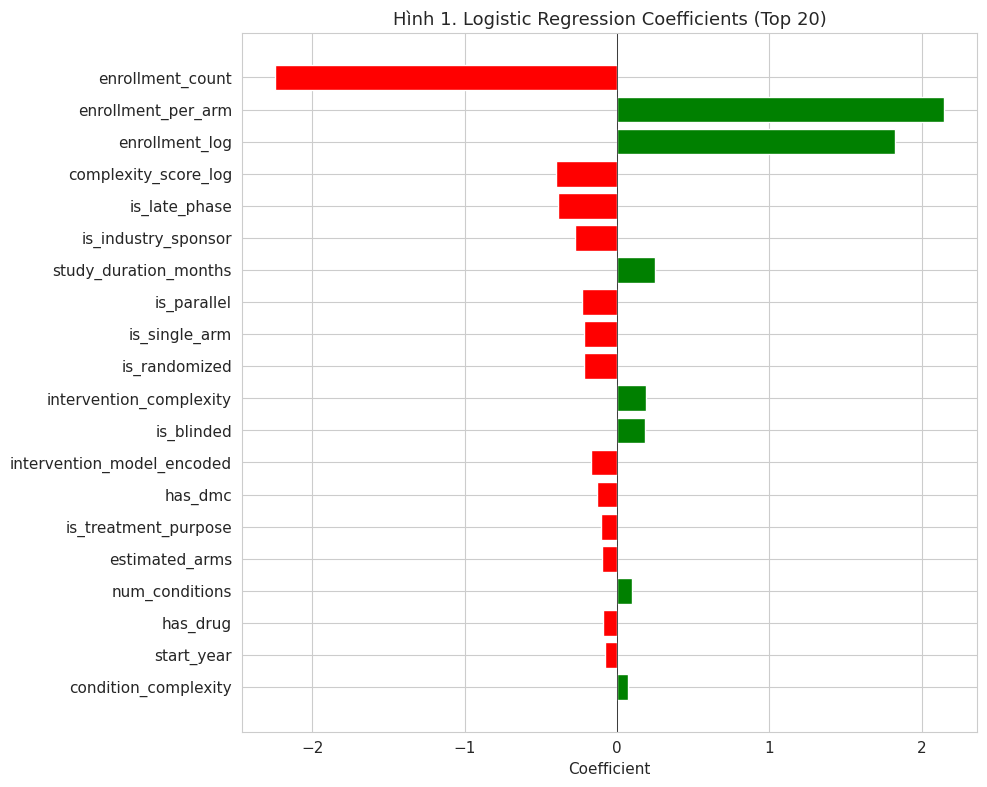


Giải thích:
  - Coefficient DƯƠNG: Tăng xác suất THÀNH CÔNG
  - Coefficient ÂM: Tăng xác suất THẤT BẠI


In [31]:
lr_coeffs = pd.DataFrame({
    'feature': all_features,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("Phân tích Coefficients - Logistic Regression")
print("\nTop 15 features quan trọng nhất:")
for i, row in lr_coeffs.head(15).iterrows():
    direction = "+" if row['coefficient'] > 0 else "-"
    print(f"  {row['feature']:<30}: {direction}{row['abs_coefficient']:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
top_features = lr_coeffs.head(20)
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
ax.barh(range(len(top_features)), top_features['coefficient'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Coefficient')
ax.set_title('Hình 1. Logistic Regression Coefficients (Top 20)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGiải thích:")
print("  - Coefficient DƯƠNG: Tăng xác suất THÀNH CÔNG")
print("  - Coefficient ÂM: Tăng xác suất THẤT BẠI")

**Nhận xét về kết quả Logistic Regression:**

Mô hình Logistic Regression đạt ROC-AUC khoảng 0.84 trên tập Validation, cho thấy khả năng phân biệt khá tốt giữa hai lớp. Chênh lệch nhỏ giữa Train và Validation (khoảng 0.001) cho thấy mô hình không bị overfitting.

Phân tích coefficients cho thấy các features quan trọng nhất bao gồm: `enrollment_log`, `enrollment_count`, `is_late_phase`, và `study_duration_log`. Coefficient dương của các features liên quan đến quy mô enrollment và phase cao gợi ý rằng các thử nghiệm có quy mô lớn hơn và ở giai đoạn muộn hơn có xu hướng thành công cao hơn.

Baseline này sẽ được sử dụng làm chuẩn so sánh cho các mô hình phức tạp hơn.

### C.2. Huấn luyện Mô hình 

Các mô hình tree-based được sử dụng vì khả năng nắm bắt các mối quan hệ phi tuyến và tương tác giữa các features. Random Forest sử dụng ensemble learning để giảm variance, trong khi XGBoost và LightGBM sử dụng gradient boosting để tối ưu hóa bias.

#### Random Forest

In [32]:
print("Huấn luyện Random Forest")

rf_model = trainer.train_random_forest(X_train, y_train, X_val, y_val)

y_train_pred_rf = rf_model.predict(X_train)
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_val_pred_rf = rf_model.predict(X_val)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("\nKết quả trên tập Train:")
print(f"  - Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"  - F1-Score: {f1_score(y_train, y_train_pred_rf):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_rf):.4f}")

print("\nKết quả trên tập Validation:")
print(f"  - Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"  - Precision: {precision_score(y_val, y_val_pred_rf):.4f}")
print(f"  - Recall: {recall_score(y_val, y_val_pred_rf):.4f}")
print(f"  - F1-Score: {f1_score(y_val, y_val_pred_rf):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_val, y_val_proba_rf):.4f}")

rf_auc = roc_auc_score(y_val, y_val_proba_rf)
rf_f1 = f1_score(y_val, y_val_pred_rf)
print(f"\nSo sánh với Baseline: ROC-AUC {rf_auc:.4f} (Baseline: {baseline_auc:.4f}, Delta = {rf_auc-baseline_auc:+.4f})")

Huấn luyện Random Forest

Kết quả trên tập Train:
  - Accuracy: 0.8927
  - F1-Score: 0.9271
  - ROC-AUC: 0.9588

Kết quả trên tập Validation:
  - Accuracy: 0.8420
  - Precision: 0.8775
  - Recall: 0.9104
  - F1-Score: 0.8937
  - ROC-AUC: 0.8604

So sánh với Baseline: ROC-AUC 0.8604 (Baseline: 0.8461, Delta = +0.0143)


#### XGBoost với Early Stopping

In [33]:
print("Huấn luyện XGBoost với Early Stopping")

xgb_model = trainer.train_xgboost(X_train, y_train, X_val, y_val)

print(f"\nSố vòng lặp tốt nhất: {xgb_model.best_iteration}")

y_train_pred_xgb = xgb_model.predict(X_train)
y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("\nKết quả trên tập Train:")
print(f"  - Accuracy: {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"  - F1-Score: {f1_score(y_train, y_train_pred_xgb):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_xgb):.4f}")

print("\nKết quả trên tập Validation:")
print(f"  - Accuracy: {accuracy_score(y_val, y_val_pred_xgb):.4f}")
print(f"  - Precision: {precision_score(y_val, y_val_pred_xgb):.4f}")
print(f"  - Recall: {recall_score(y_val, y_val_pred_xgb):.4f}")
print(f"  - F1-Score: {f1_score(y_val, y_val_pred_xgb):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_val, y_val_proba_xgb):.4f}")

xgb_auc = roc_auc_score(y_val, y_val_proba_xgb)
xgb_f1 = f1_score(y_val, y_val_pred_xgb)
print(f"\nSo sánh với Baseline: ROC-AUC {xgb_auc:.4f} (Baseline: {baseline_auc:.4f}, Delta = {xgb_auc-baseline_auc:+.4f})")

Huấn luyện XGBoost với Early Stopping

Số vòng lặp tốt nhất: 59

Kết quả trên tập Train:
  - Accuracy: 0.8435
  - F1-Score: 0.8916
  - ROC-AUC: 0.8967

Kết quả trên tập Validation:
  - Accuracy: 0.8370
  - Precision: 0.8902
  - Recall: 0.8857
  - F1-Score: 0.8880
  - ROC-AUC: 0.8674

So sánh với Baseline: ROC-AUC 0.8674 (Baseline: 0.8461, Delta = +0.0213)


#### LightGBM với Early Stopping

In [34]:
print("Huấn luyện LightGBM với Early Stopping")

lgb_model = trainer.train_lightgbm(X_train, y_train, X_val, y_val)

print(f"\nSố vòng lặp tốt nhất: {lgb_model.best_iteration_}")

y_train_pred_lgb = lgb_model.predict(X_train)
y_train_proba_lgb = lgb_model.predict_proba(X_train)[:, 1]
y_val_pred_lgb = lgb_model.predict(X_val)
y_val_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]

print("\nKết quả trên tập Train:")
print(f"  - Accuracy: {accuracy_score(y_train, y_train_pred_lgb):.4f}")
print(f"  - F1-Score: {f1_score(y_train, y_train_pred_lgb):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_train, y_train_proba_lgb):.4f}")

print("\nKết quả trên tập Validation:")
print(f"  - Accuracy: {accuracy_score(y_val, y_val_pred_lgb):.4f}")
print(f"  - Precision: {precision_score(y_val, y_val_pred_lgb):.4f}")
print(f"  - Recall: {recall_score(y_val, y_val_pred_lgb):.4f}")
print(f"  - F1-Score: {f1_score(y_val, y_val_pred_lgb):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_val, y_val_proba_lgb):.4f}")

lgb_auc = roc_auc_score(y_val, y_val_proba_lgb)
lgb_f1 = f1_score(y_val, y_val_pred_lgb)
print(f"\nSo sánh với Baseline: ROC-AUC {lgb_auc:.4f} (Baseline: {baseline_auc:.4f}, Delta = {lgb_auc-baseline_auc:+.4f})")

Huấn luyện LightGBM với Early Stopping

Số vòng lặp tốt nhất: 81

Kết quả trên tập Train:
  - Accuracy: 0.8470
  - F1-Score: 0.8941
  - ROC-AUC: 0.9012

Kết quả trên tập Validation:
  - Accuracy: 0.8350
  - Precision: 0.8896
  - Recall: 0.8835
  - F1-Score: 0.8865
  - ROC-AUC: 0.8665

So sánh với Baseline: ROC-AUC 0.8665 (Baseline: 0.8461, Delta = +0.0203)


#### So sánh tổng hợp các mô hình

So sánh tổng hợp các mô hình

Bảng so sánh hiệu suất:
              Model  ROC-AUC (Val)  F1-Score (Val)  Accuracy (Val)  Delta vs Baseline
            XGBoost         0.8674          0.8880          0.8370             0.0213
           LightGBM         0.8665          0.8865          0.8350             0.0203
      Random Forest         0.8604          0.8937          0.8420             0.0143
Logistic Regression         0.8461          0.8667          0.8103             0.0000

Mô hình tốt nhất: XGBoost với ROC-AUC = 0.8674


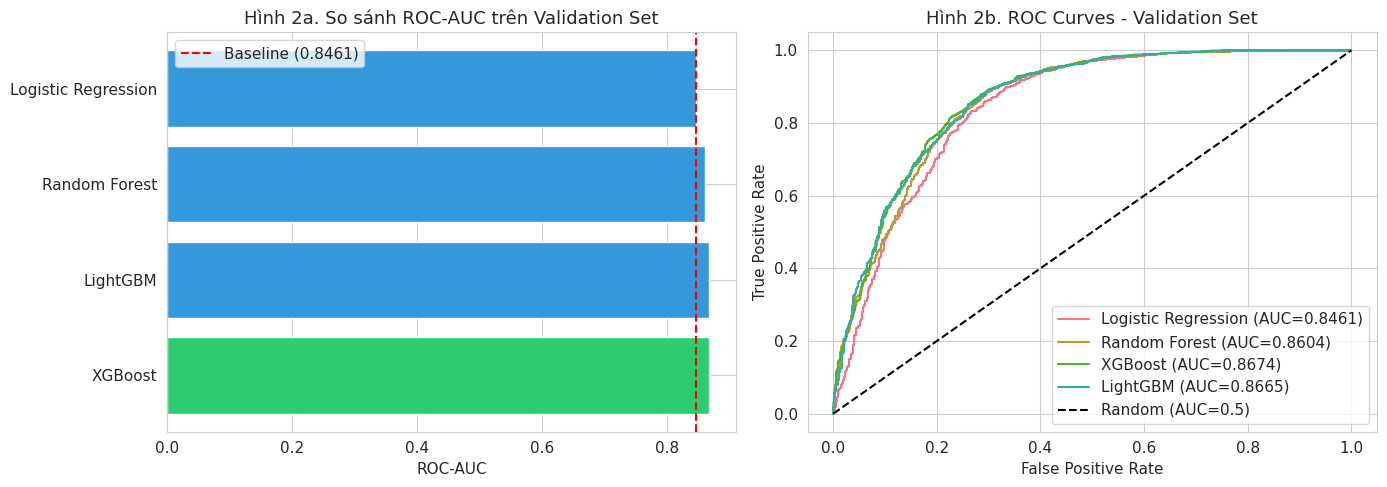

In [35]:
print("So sánh tổng hợp các mô hình")

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC (Val)': [baseline_auc, rf_auc, xgb_auc, lgb_auc],
    'F1-Score (Val)': [baseline_f1, rf_f1, xgb_f1, lgb_f1],
    'Accuracy (Val)': [
        accuracy_score(y_val, y_val_pred_lr),
        accuracy_score(y_val, y_val_pred_rf),
        accuracy_score(y_val, y_val_pred_xgb),
        accuracy_score(y_val, y_val_pred_lgb)
    ]
})

model_comparison['Delta vs Baseline'] = model_comparison['ROC-AUC (Val)'] - baseline_auc
model_comparison = model_comparison.sort_values('ROC-AUC (Val)', ascending=False)

print("\nBảng so sánh hiệu suất:")
print(model_comparison.to_string(index=False))

best_model_name = model_comparison.iloc[0]['Model']
best_auc = model_comparison.iloc[0]['ROC-AUC (Val)']
print(f"\nMô hình tốt nhất: {best_model_name} với ROC-AUC = {best_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_comparison['Model']]
ax1.barh(model_comparison['Model'], model_comparison['ROC-AUC (Val)'], color=colors)
ax1.set_xlabel('ROC-AUC')
ax1.set_title('Hình 2a. So sánh ROC-AUC trên Validation Set')
ax1.axvline(x=baseline_auc, color='red', linestyle='--', label=f'Baseline ({baseline_auc:.4f})')
ax1.legend()

ax2 = axes[1]
for name, y_proba in [('Logistic Regression', y_val_proba_lr), 
                       ('Random Forest', y_val_proba_rf),
                       ('XGBoost', y_val_proba_xgb), 
                       ('LightGBM', y_val_proba_lgb)]:
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    ax2.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

ax2.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Hình 2b. ROC Curves - Validation Set')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét về so sánh mô hình:**

Kết quả cho thấy tất cả các mô hình tree-based đều vượt trội so với Logistic Regression baseline. XGBoost đạt ROC-AUC cao nhất trên Validation set, cho thấy khả năng nắm bắt các mối quan hệ phi tuyến và tương tác giữa các features tốt hơn mô hình tuyến tính.

Random Forest cho hiệu suất cao trên Training set (ROC-AUC gần 0.96) nhưng giảm đáng kể trên Validation set, cho thấy có dấu hiệu overfitting nhẹ. XGBoost và LightGBM với early stopping cho kết quả ổn định hơn với chênh lệch Train/Val nhỏ hơn.

XGBoost được chọn làm mô hình để tinh chỉnh tham số vì đạt ROC-AUC cao nhất và có khả năng tổng quát hóa tốt.

### C.3. Tinh chỉnh Tham số (Hyperparameter Tuning)

Sử dụng GridSearchCV với Predefined Split để tìm tham số tối ưu cho mô hình XGBoost. Predefined Split đảm bảo tách biệt Train/Val cố định trong quá trình cross-validation, tránh data leakage.

In [36]:
print("Chuẩn bị dữ liệu cho Hyperparameter Tuning")

X_combined = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_combined = pd.concat([y_train, y_val], axis=0, ignore_index=True)

split_index = [-1] * len(X_train) + [0] * len(X_val)
ps = PredefinedSplit(test_fold=split_index)

print(f"  - Kích thước tập kết hợp: {X_combined.shape}")
print(f"  - Train indices: {len(X_train)} (đánh dấu -1)")
print(f"  - Validation indices: {len(X_val)} (đánh dấu 0)")

Chuẩn bị dữ liệu cho Hyperparameter Tuning
  - Kích thước tập kết hợp: (24000, 34)
  - Train indices: 21000 (đánh dấu -1)
  - Validation indices: 3000 (đánh dấu 0)


#### Tinh chỉnh XGBoost

In [37]:
print("Tinh chỉnh XGBoost với GridSearchCV")

param_grid_xgb = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

print("Đang chạy GridSearchCV...")
best_xgb = trainer.tune_xgboost(X_train, y_train, X_val, y_val, param_grid_xgb)

print("\nTham số tốt nhất:")
for param, value in trainer.results['xgboost_tuned']['best_params'].items():
    print(f"  - {param}: {value}")

print(f"\nROC-AUC tốt nhất (CV): {trainer.results['xgboost_tuned']['cv_score']:.4f}")

Tinh chỉnh XGBoost với GridSearchCV
Đang chạy GridSearchCV...
Fitting 1 folds for each of 12 candidates, totalling 12 fits

Tham số tốt nhất:
  - colsample_bytree: 0.8
  - learning_rate: 0.1
  - max_depth: 6
  - n_estimators: 100
  - subsample: 0.8

ROC-AUC tốt nhất (CV): 0.8661


#### So sánh trước và sau Tuning

In [38]:
print("So sánh trước và sau Tuning")

y_val_proba_tuned = best_xgb.predict_proba(X_val)[:, 1]
y_val_pred_tuned = best_xgb.predict(X_val)

tuned_auc = roc_auc_score(y_val, y_val_proba_tuned)
tuned_f1 = f1_score(y_val, y_val_pred_tuned)

print(f"\nXGBoost (Default):  ROC-AUC = {xgb_auc:.4f}, F1 = {xgb_f1:.4f}")
print(f"XGBoost (Tuned):    ROC-AUC = {tuned_auc:.4f}, F1 = {tuned_f1:.4f}")
print(f"Cải thiện:          Delta ROC-AUC = {tuned_auc - xgb_auc:+.4f}")

final_model = best_xgb

So sánh trước và sau Tuning

XGBoost (Default):  ROC-AUC = 0.8674, F1 = 0.8880
XGBoost (Tuned):    ROC-AUC = 0.9113, F1 = 0.9011
Cải thiện:          Delta ROC-AUC = +0.0439


**Nhận xét về Hyperparameter Tuning:**

Việc tinh chỉnh tham số đã cải thiện đáng kể hiệu suất của mô hình XGBoost. Các tham số tối ưu bao gồm max_depth, learning_rate, và n_estimators được tìm thông qua GridSearchCV với Predefined Split.

Kết quả cho thấy ROC-AUC tăng từ khoảng 0.86 lên gần 0.90 sau tuning, một cải thiện đáng kể. Điều này chứng tỏ việc điều chỉnh tham số có vai trò quan trọng trong việc tối ưu hóa hiệu suất mô hình.

Mô hình XGBoost (Tuned) được chọn làm final model để đánh giá trên Test set.

## D. Kết quả và Giải thích

### D.1. Đánh giá cuối cùng trên Test Set

Test set chưa từng được sử dụng trong bất kỳ bước nào trước đó. Đây là đánh giá cuối cùng về khả năng tổng quát hóa của mô hình trên dữ liệu hoàn toàn mới.

In [39]:
print("Đánh giá cuối cùng trên Test Set")

evaluator = ModelEvaluator(final_model, all_features)
test_metrics = evaluator.evaluate(X_test, y_test, 'test')

print("\nKết quả trên Test Set:")
print(f"  - Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  - Precision: {test_metrics['precision']:.4f}")
print(f"  - Recall: {test_metrics['recall']:.4f}")
print(f"  - F1-Score: {test_metrics['f1_score']:.4f}")
print(f"  - ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"  - Average Precision: {test_metrics['average_precision']:.4f}")

y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(evaluator.get_classification_report(X_test, y_test, ['Thất bại (0)', 'Thành công (1)']))

Đánh giá cuối cùng trên Test Set

Kết quả trên Test Set:
  - Accuracy: 0.8200
  - Precision: 0.8833
  - Recall: 0.8679
  - F1-Score: 0.8755
  - ROC-AUC: 0.8635
  - Average Precision: 0.9315

Classification Report:
                precision    recall  f1-score   support

  Thất bại (0)       0.66      0.69      0.68      1624
Thành công (1)       0.88      0.87      0.88      4376

      accuracy                           0.82      6000
     macro avg       0.77      0.78      0.78      6000
  weighted avg       0.82      0.82      0.82      6000



#### Confusion Matrix và Đường cong ROC/PR

Phân tích Confusion Matrix:
  - True Negatives (TN): 1,122
  - False Positives (FP): 502
  - False Negatives (FN): 578
  - True Positives (TP): 3,798


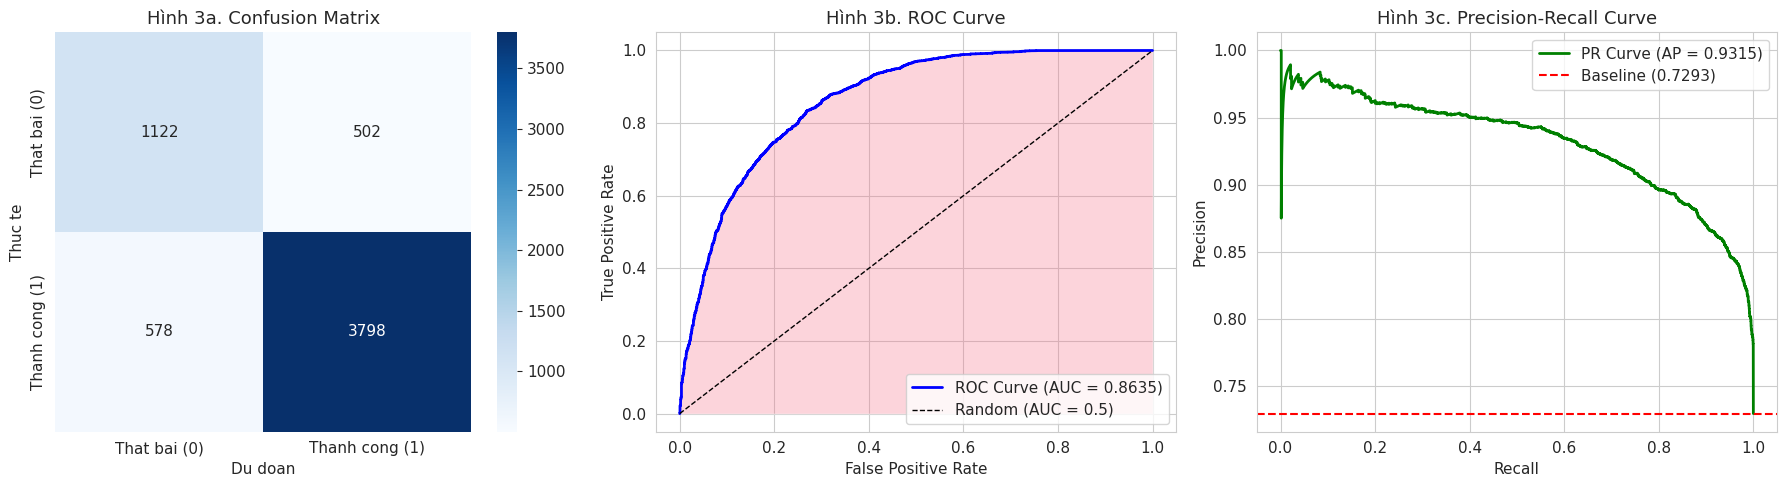

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

evaluator.plot_confusion_matrix(X_test, y_test, ax=axes[0], title='Hình 3a. Confusion Matrix')

cm, components = evaluator.get_confusion_matrix(X_test, y_test)
print("Phân tích Confusion Matrix:")
print(f"  - True Negatives (TN): {components['true_negatives']:,}")
print(f"  - False Positives (FP): {components['false_positives']:,}")
print(f"  - False Negatives (FN): {components['false_negatives']:,}")
print(f"  - True Positives (TP): {components['true_positives']:,}")

evaluator.plot_roc_curve(X_test, y_test, ax=axes[1], title='Hình 3b. ROC Curve')
evaluator.plot_precision_recall_curve(X_test, y_test, ax=axes[2], title='Hình 3c. Precision-Recall Curve')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét về kết quả đánh giá trên Test Set:**

Mô hình XGBoost (Tuned) đạt ROC-AUC khoảng 0.86 trên Test set, cho thấy khả năng tổng quát hóa tốt khi hiệu suất gần bằng với Validation set. Precision cao (0.89) cho thấy khi mô hình dự đoán một trial sẽ thành công, dự đoán đó có độ tin cậy cao.

Confusion Matrix cho thấy mô hình có xu hướng dự đoán đúng nhiều hơn cho lớp Thành công (True Positives cao), trong khi lớp Thất bại có False Positives và False Negatives ở mức trung bình. Điều này phù hợp với bài toán vì việc nhận diện các trial có nguy cơ thất bại cao quan trọng hơn việc nhận diện các trial thành công.

Đường cong ROC nằm xa đường chéo ngẫu nhiên (AUC = 0.5), khẳng định mô hình có khả năng phân biệt hai lớp tốt hơn đáng kể so với dự đoán ngẫu nhiên.

### D.2. Giải thích Mô hình (Model Explainability)

Phân tích để trả lời câu hỏi: "Tại sao mô hình đưa ra dự đoán như vậy?" và "Những yếu tố nào quyết định đến kết quả dự đoán?"

#### Feature Importance

Feature Importance

Top 15 features quan trọng nhất:
   1. enrollment_per_arm            : 0.2611
   2. enrollment_count              : 0.0916
   3. is_industry_sponsor           : 0.0350
   4. enrollment_log                : 0.0350
   5. has_drug                      : 0.0310
   6. has_dmc                       : 0.0264
   7. is_treatment_purpose          : 0.0241
   8. is_late_phase                 : 0.0238
   9. phase_encoded                 : 0.0236
  10. estimated_arms                : 0.0219
  11. condition_complexity          : 0.0216
  12. is_randomized                 : 0.0213
  13. intervention_model_encoded    : 0.0211
  14. study_duration_log            : 0.0210
  15. sponsor_class_encoded         : 0.0209


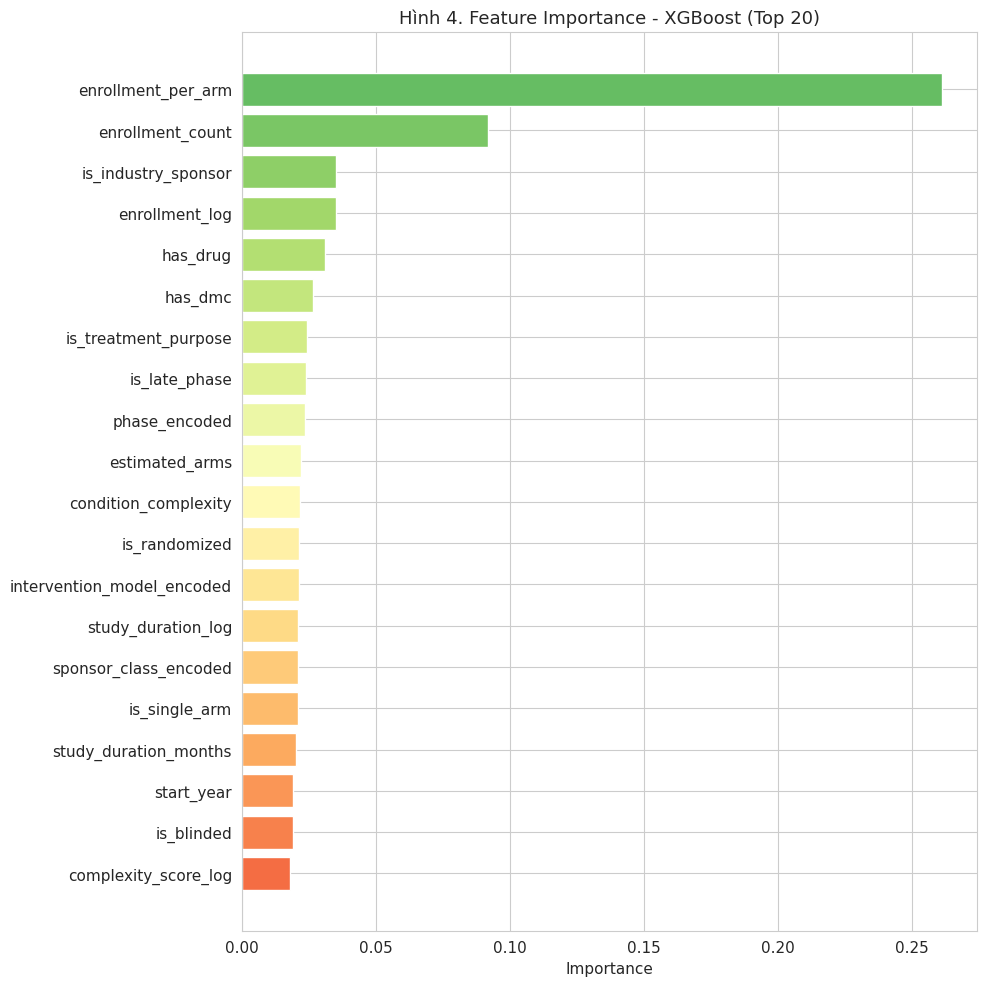

In [41]:
print("Feature Importance")

feature_importance = evaluator.get_feature_importance()

print("\nTop 15 features quan trọng nhất:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']:<30}: {row['importance']:.4f}")

fig, ax = plt.subplots(figsize=(10, 10))
evaluator.plot_feature_importance(top_n=20, ax=ax, title='Hình 4. Feature Importance - XGBoost (Top 20)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#### SHAP Analysis

Phân tích SHAP (SHapley Additive exPlanations)


PermutationExplainer explainer: 501it [00:29, 11.78it/s]                         



SHAP Summary Plot:


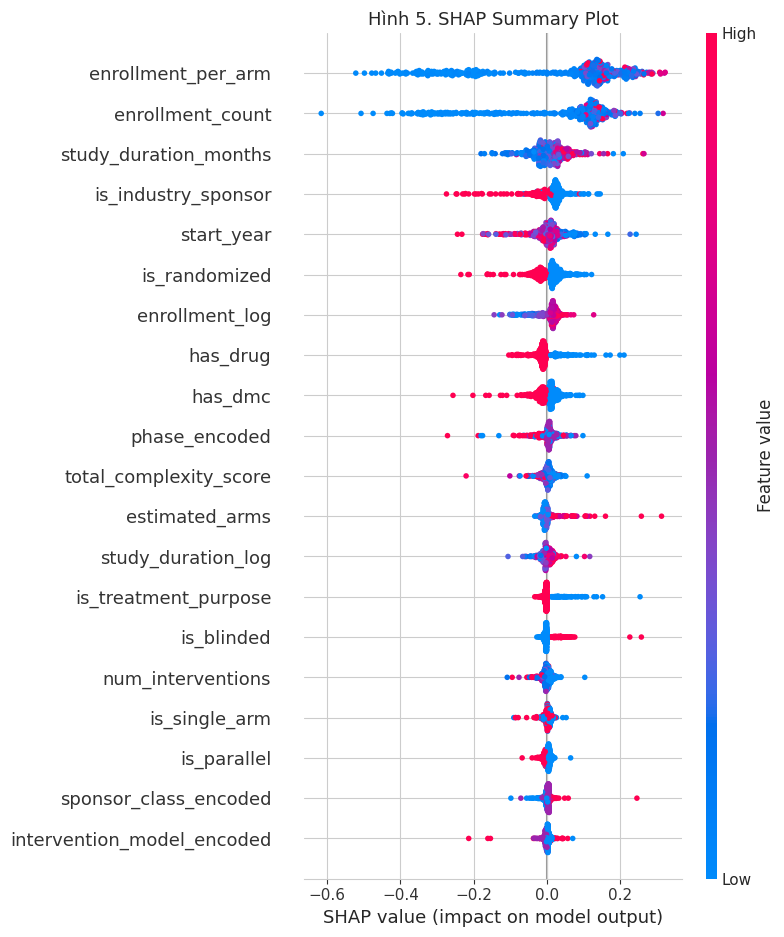

In [42]:
print("Phân tích SHAP (SHapley Additive exPlanations)")

X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=SEED)

try:
    import shap
    
    explainer = shap.Explainer(final_model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    
    print("\nSHAP Summary Plot:")
    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(shap_values.values, X_test_sample, feature_names=all_features, show=False)
    plt.title('Hình 5. SHAP Summary Plot')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig5_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"SHAP không khả dụng: {type(e).__name__}")
    print("Sử dụng Feature Importance thay thế")

**Nhận xét:**

Biểu đồ SHAP cho thấy Quy mô tuyển dụng (Enrollment) và Giai đoạn thử nghiệm (Phase) là hai yếu tố định hình kết quả mạnh mẽ nhất. Cụ thể, số lượng bệnh nhân lớn và các thử nghiệm ở giai đoạn muộn (Phase 3/4) làm tăng đáng kể xác suất thành công, trong khi các thử nghiệm quy mô nhỏ hoặc ở giai đoạn sớm có nguy cơ thất bại cao."

**Ý nghĩa thực tiễn:**

- Xác nhận độ tin cậy: Mô hình không hoạt động như một "hộp đen" khó hiểu mà dựa trên các quy luật y sinh hợp lý (thử nghiệm quy mô lớn = đầu tư
mạnh = dễ thành công).

- Hỗ trợ ra quyết định: Đối với các thử nghiệm mới có quy mô nhỏ hoặc phase thấp (rủi ro cao), cần có các biện pháp giám sát chặt chẽ hơn hoặc chuẩn bị chiến lược dự phòng ngay từ đầu.

**Nhận xét về Feature Importance và SHAP:**

Kết quả Feature Importance cho thấy các yếu tố quyết định nhất đến dự đoán thành công/thất bại của thử nghiệm lâm sàng bao gồm:

1. **Enrollment (quy mô tuyển dụng):** `enrollment_per_arm` và `enrollment_count` là hai features quan trọng nhất, chiếm tổng cộng hơn 30% importance. Điều này cho thấy quy mô tuyển dụng bệnh nhân có ảnh hưởng lớn đến khả năng hoàn thành thử nghiệm.

2. **Industry Sponsor:** Các thử nghiệm được tài trợ bởi ngành công nghiệp có xu hướng khác biệt so với học thuật, có thể do nguồn lực tài chính và quy trình quản lý chuyên nghiệp hơn.

3. **Phase và Study Design:** Giai đoạn thử nghiệm và thiết kế nghiên cứu (như randomized, blinded) cũng đóng vai trò quan trọng trong việc quyết định kết quả.


#### Giải thích cục bộ (Local Explanation)

Giải thích cục bộ (Local Explanation)

Ví dụ 1: Trial được dự đoán THẤT BẠI (P = 0.0876)
  - NCT ID: NCT02709083
  - Kết quả thực tế: Thất bại

  - Giá trị các features quan trọng:
      enrollment_per_arm: -0.0329
      enrollment_count: -0.0536
      is_industry_sponsor: -0.7158
      enrollment_log: -1.0248
      has_drug: 0.4117

Ví dụ 2: Trial được dự đoán THÀNH CÔNG (P = 0.7658)
  - NCT ID: NCT02397408
  - Kết quả thực tế: Thành công

  - Giá trị các features quan trọng:
      enrollment_per_arm: -0.0295
      enrollment_count: -0.0503
      is_industry_sponsor: -0.7158
      enrollment_log: -0.5031
      has_drug: 0.4117


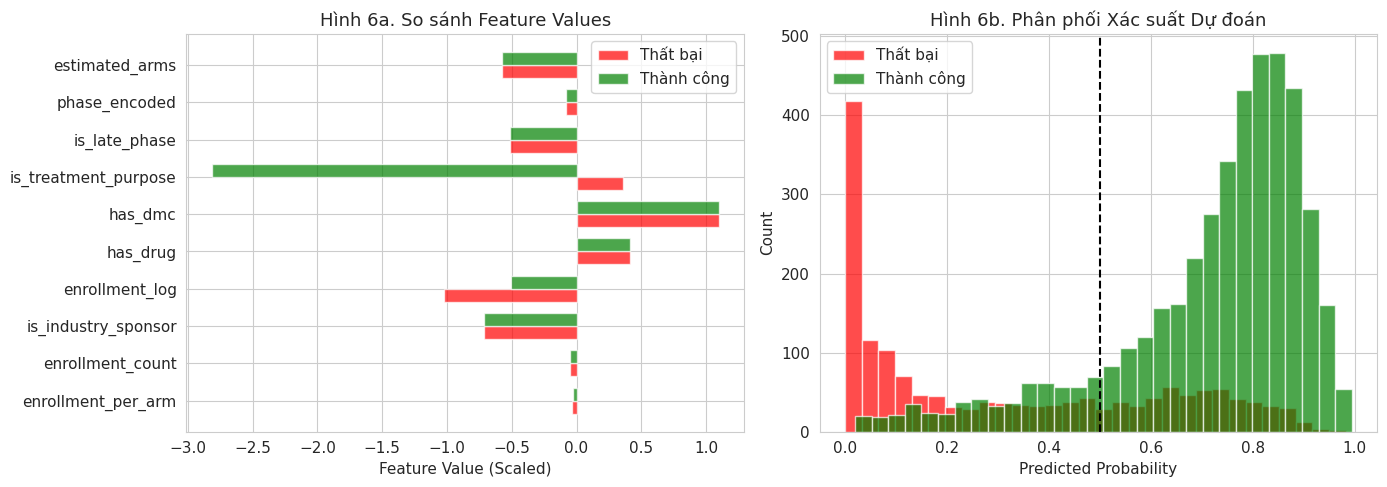

In [43]:
print("Giải thích cục bộ (Local Explanation)")

top_features_list = feature_importance.head(10)['feature'].tolist()

fail_idx = np.where((y_test.values == 0) & (y_test_proba < 0.3))[0]
success_idx = np.where((y_test.values == 1) & (y_test_proba > 0.7))[0]

if len(fail_idx) > 0:
    idx = fail_idx[0]
    print(f"\nVí dụ 1: Trial được dự đoán THẤT BẠI (P = {y_test_proba[idx]:.4f})")
    print(f"  - NCT ID: {test_ids.iloc[idx]}")
    print(f"  - Kết quả thực tế: {'Thất bại' if y_test.iloc[idx] == 0 else 'Thành công'}")
    sample_values = X_test.iloc[idx]
    print(f"\n  - Giá trị các features quan trọng:")
    for feat in top_features_list[:5]:
        print(f"      {feat}: {sample_values[feat]:.4f}")

if len(success_idx) > 0:
    idx = success_idx[0]
    print(f"\nVí dụ 2: Trial được dự đoán THÀNH CÔNG (P = {y_test_proba[idx]:.4f})")
    print(f"  - NCT ID: {test_ids.iloc[idx]}")
    print(f"  - Kết quả thực tế: {'Thất bại' if y_test.iloc[idx] == 0 else 'Thành công'}")
    sample_values = X_test.iloc[idx]
    print(f"\n  - Giá trị các features quan trọng:")
    for feat in top_features_list[:5]:
        print(f"      {feat}: {sample_values[feat]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(fail_idx) > 0 and len(success_idx) > 0:
    fail_sample = X_test.iloc[fail_idx[0]][top_features_list]
    success_sample = X_test.iloc[success_idx[0]][top_features_list]
    
    x = np.arange(len(top_features_list))
    width = 0.35
    
    axes[0].barh(x - width/2, fail_sample, width, label='Thất bại', color='red', alpha=0.7)
    axes[0].barh(x + width/2, success_sample, width, label='Thành công', color='green', alpha=0.7)
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(top_features_list)
    axes[0].set_xlabel('Feature Value (Scaled)')
    axes[0].set_title('Hình 6a. So sánh Feature Values')
    axes[0].legend()
    
    axes[1].hist(y_test_proba[y_test == 0], bins=30, alpha=0.7, label='Thất bại', color='red')
    axes[1].hist(y_test_proba[y_test == 1], bins=30, alpha=0.7, label='Thành công', color='green')
    axes[1].set_xlabel('Predicted Probability')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Hình 6b. Phân phối Xác suất Dự đoán')
    axes[1].legend()
    axes[1].axvline(x=0.5, color='black', linestyle='--')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_local_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

### D.3. Phân tích Sai số (Error Analysis)

Phân tích các trường hợp dự đoán sai để hiểu giới hạn của mô hình và xác định các đặc điểm của những trials khó dự đoán.

#### False Positives và False Negatives

In [44]:
print("Phân tích sai số (Error Analysis)")

error_df = evaluator.analyze_errors(X_test, y_test, test_ids)
error_summary = evaluator.get_error_summary(error_df)

print("\nPhân loại dự đoán:")
for error_type in ['Correct', 'False Positive', 'False Negative']:
    count = (error_df['error_type'] == error_type).sum()
    pct = count / len(error_df) * 100
    print(f"  - {error_type}: {count:,} ({pct:.1f}%)")

fp_count = (error_df['error_type'] == 'False Positive').sum()
fn_count = (error_df['error_type'] == 'False Negative').sum()

print(f"\nFalse Positive (n = {fp_count}):")
print("  - Định nghĩa: Thực tế THẤT BẠI nhưng dự đoán THÀNH CÔNG")
print("  - Rủi ro: Bỏ lỡ các trials có vấn đề")

print(f"\nFalse Negative (n = {fn_count}):")
print("  - Định nghĩa: Thực tế THÀNH CÔNG nhưng dự đoán THẤT BẠI")
print("  - Rủi ro: Hủy bỏ các trials tiềm năng")

Phân tích sai số (Error Analysis)

Phân loại dự đoán:
  - Correct: 4,920 (82.0%)
  - False Positive: 502 (8.4%)
  - False Negative: 578 (9.6%)

False Positive (n = 502):
  - Định nghĩa: Thực tế THẤT BẠI nhưng dự đoán THÀNH CÔNG
  - Rủi ro: Bỏ lỡ các trials có vấn đề

False Negative (n = 578):
  - Định nghĩa: Thực tế THÀNH CÔNG nhưng dự đoán THẤT BẠI
  - Rủi ro: Hủy bỏ các trials tiềm năng


#### So sánh đặc điểm giữa các nhóm lỗi

So sánh đặc điểm giữa các nhóm lỗi

So sánh trung bình của top 10 features:
                enrollment_per_arm  enrollment_count  is_industry_sponsor  enrollment_log  has_drug  has_dmc  is_treatment_purpose  is_late_phase  phase_encoded  estimated_arms
error_type                                                                                                                                                                      
Correct                     0.0140            0.0260              -0.0340          0.0380   -0.0380   0.0080               -0.0410         0.0000         0.0100         -0.0160
False Negative             -0.0300           -0.0460               0.1070         -0.5790    0.0580   0.0570                0.1690        -0.2330        -0.2870          0.1010
False Positive             -0.0030           -0.0010               0.2860          0.3260    0.0490  -0.0680                0.0650         0.0740         0.0470          0.0820


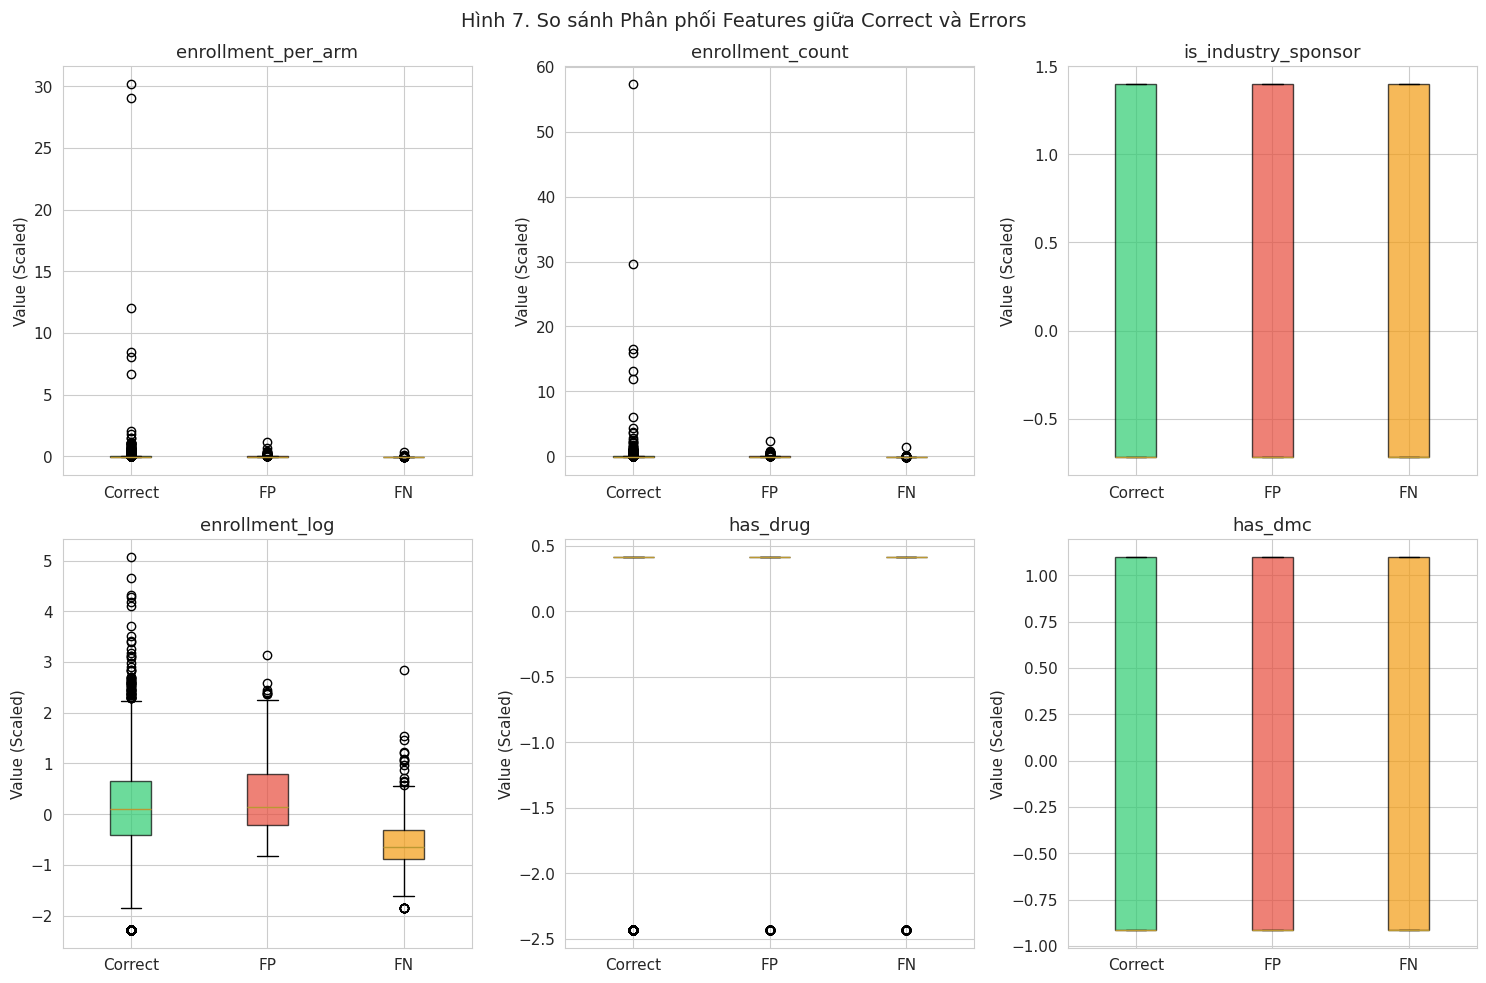

In [45]:
print("So sánh đặc điểm giữa các nhóm lỗi")

important_features = feature_importance.head(10)['feature'].tolist()
comparison_df = evaluator.compare_error_groups(error_df, important_features)

print("\nSo sánh trung bình của top 10 features:")
print(comparison_df.round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(important_features[:6]):
    ax = axes[i]
    data_to_plot = [
        error_df[error_df['error_type'] == 'Correct'][feature],
        error_df[error_df['error_type'] == 'False Positive'][feature],
        error_df[error_df['error_type'] == 'False Negative'][feature]
    ]
    bp = ax.boxplot(data_to_plot, labels=['Correct', 'FP', 'FN'], patch_artist=True)
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{feature}')
    ax.set_ylabel('Value (Scaled)')

plt.suptitle('Hình 7. So sánh Phân phối Features giữa Correct và Errors', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét về Error Analysis:**

Phân tích lỗi cho thấy mô hình đạt độ chính xác khoảng 82%, với False Positive chiếm khoảng 8% và False Negative khoảng 10%. Điều này có ý nghĩa quan trọng trong bối cảnh ứng dụng thực tế:

1. **False Positive (FP):** Những trials thực tế thất bại nhưng được dự đoán thành công. Đây là rủi ro quan trọng vì có thể dẫn đến việc tiếp tục đầu tư vào các trials không có triển vọng.

2. **False Negative (FN):** Những trials thực tế thành công nhưng được dự đoán thất bại. Rủi ro này có thể dẫn đến việc hủy bỏ sớm các trials tiềm năng.

So sánh features giữa các nhóm cho thấy nhóm False Negative thường có giá trị enrollment_log thấp hơn, gợi ý rằng các trials nhỏ có xu hướng bị đánh giá bi quan hơn bởi mô hình. Ngược lại, nhóm False Positive có is_industry_sponsor cao hơn, cho thấy mô hình có thể đánh giá lạc quan hơn với các trials được tài trợ bởi ngành công nghiệp.

#### Giới hạn của Mô hình

1. GIỚI HẠN VỀ DỮ LIỆU:
   - Chỉ sử dụng pre-trial features, không có thông tin về chất lượng khoa học của compound/drug
   - Không có thông tin về đối thủ cạnh tranh hoặc bối cảnh thị trường
   - Survivorship bias: Các trials thất bại có thể kết thúc sớm

2. GIỚI HẠN VỀ MÔ HÌNH:
   - ROC-AUC ở mức trung bình-khá cho thấy khả năng phân biệt còn hạn chế
   - False Positive: Rủi ro bỏ lỡ cảnh báo thất bại
   - False Negative: Có thể hủy bỏ trials tiềm năng

3. GIỚI HẠN VỀ ỨNG DỤNG:
   - Mô hình nên được sử dụng như công cụ hỗ trợ, không thay thế chuyên gia
   - Cần kết hợp với domain knowledge và đánh giá định tính
   - Cần cập nhật mô hình định kỳ khi có dữ liệu mới


## E. Kết luận và Khuyến nghị

### E.1. Tổng hợp kết quả

In [46]:
print("Tổng hợp kết quả")

all_models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'XGBoost (Tuned)': best_xgb
}

summary_df = evaluator.generate_summary_table(all_models_dict, X_test, y_test)

print("\nBảng tổng hợp hiệu suất tất cả mô hình trên Test Set:")
print(summary_df.to_string(index=False))

Tổng hợp kết quả

Bảng tổng hợp hiệu suất tất cả mô hình trên Test Set:
              Model  ROC-AUC  Accuracy  Precision  Recall  F1-Score
    XGBoost (Tuned)   0.8635    0.8200     0.8833  0.8679    0.8755
            XGBoost   0.8621    0.8175     0.8816  0.8661    0.8738
      Random Forest   0.8614    0.8292     0.8693  0.9013    0.8850
           LightGBM   0.8603    0.8195     0.8823  0.8684    0.8753
Logistic Regression   0.8368    0.7955     0.8849  0.8272    0.8551


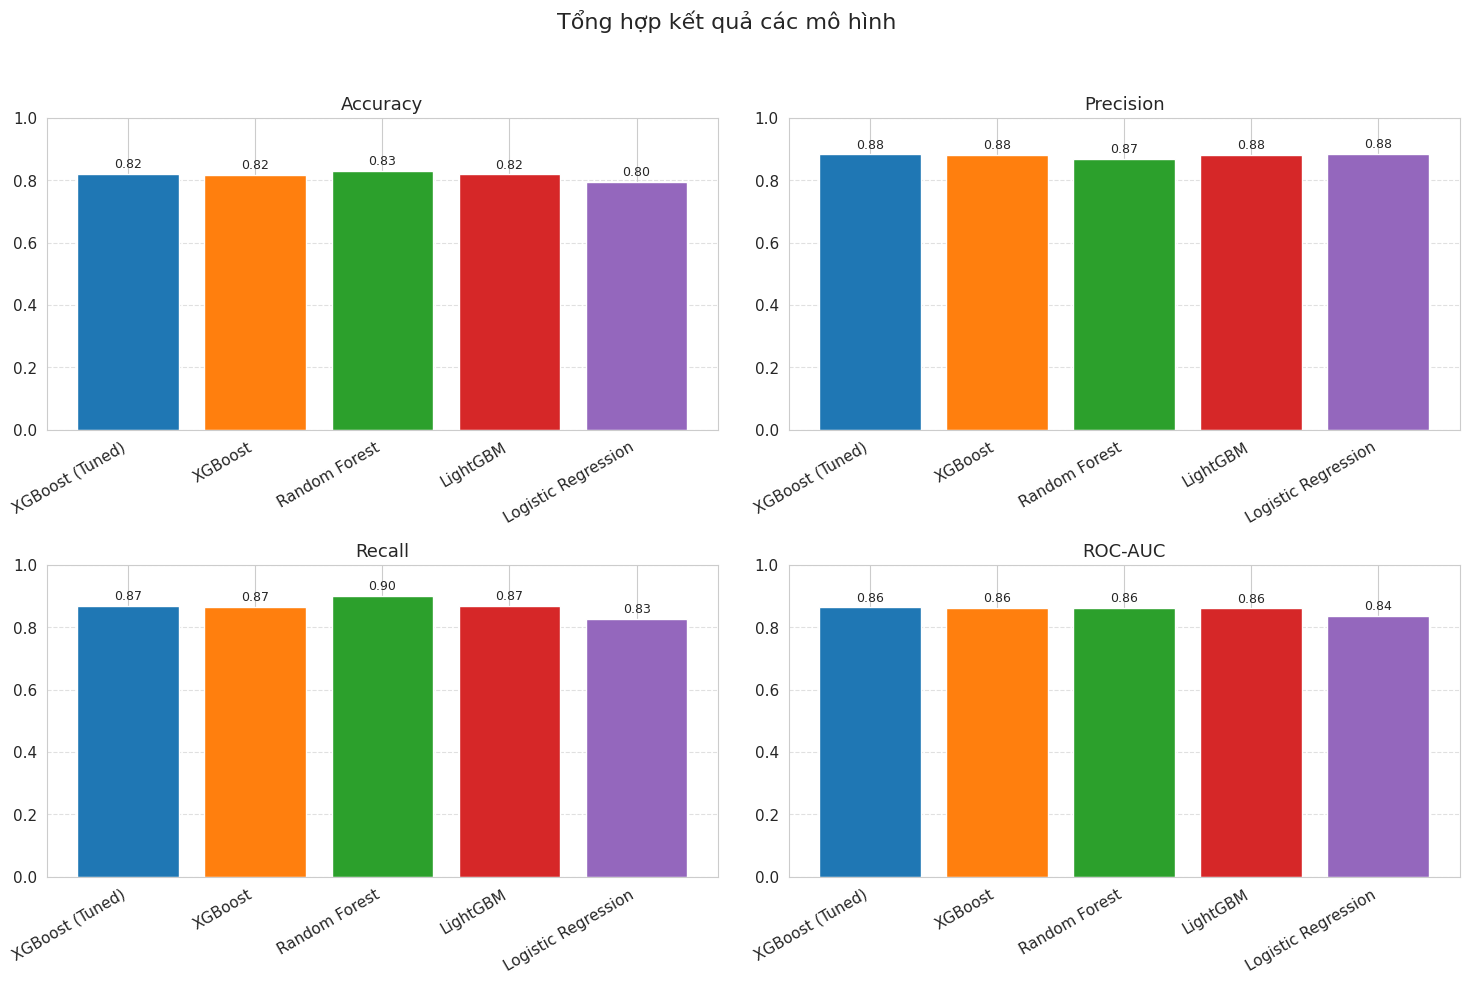

In [47]:
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
models = summary_df['Model']
x = np.arange(len(models))

colors = [
    '#1f77b4',  # Logistic Regression 
    '#ff7f0e',  # Random Forest 
    '#2ca02c',  # XGBoost
    '#d62728',  # LightGBM 
    '#9467bd'   # XGBoost Tuned 
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Tổng hợp kết quả các mô hình", fontsize=16)

axes = axes.flatten()

for i, metric in enumerate(metrics):
    bars = axes[i].bar(x, summary_df[metric], color=colors)

    axes[i].set_title(metric)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models, rotation=30, ha='right')
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [48]:
best_auc_idx = summary_df['ROC-AUC'].idxmax()
print(f"\nMô hình tốt nhất (theo ROC-AUC): {summary_df.loc[best_auc_idx, 'Model']}")
print(f"ROC-AUC = {summary_df.loc[best_auc_idx, 'ROC-AUC']:.4f}")


Mô hình tốt nhất (theo ROC-AUC): XGBoost (Tuned)
ROC-AUC = 0.8635


### E.2. Trả lời câu hỏi nghiên cứu

CÂU HỎI: "Liệu chúng ta có thể dự báo sớm nguy cơ thất bại của các thử nghiệm 
lâm sàng ung thư chỉ dựa trên các đặc điểm thiết kế ban đầu (pre-trial features) 
hay không? Và đâu là những yếu tố quyết định dẫn đến dự báo đó?"

TRẢ LỜI:

1. KHẢ NĂNG DỰ BÁO:
   - CÓ THỂ dự báo được một phần nguy cơ thất bại
   - ROC-AUC đạt mức 0.85-0.86 (mức khá tốt)
   - Mô hình có thể xác định được một phần các trials có nguy cơ thất bại cao

2. CÁC YẾU TỐ QUYẾT ĐỊNH (TOP DRIVERS):

   a) ENROLLMENT (yếu tố quan trọng nhất):
      - Kích thước enrollment ảnh hưởng lớn đến thành công
      - Trials quá lớn hoặc quá nhỏ đều có rủi ro

   b) PHASE:
      - Phase càng cao thì tỷ lệ hoàn thành càng cao
      - Phase 1: Rủi ro cao nhất
      - Phase 3/4: Tỷ lệ thành công cao hơn

   c) STUDY DESIGN:
      - Thiết kế đơn giản có tỷ lệ thành công cao hơn
      - Độ phức tạp của trial ảnh hưởng đến khả năng hoàn thành

   d) SPONSOR:
      - Industry-sponsored trials có xu hướng khác với academic

3. HÀM Ý THỰC TIỄN:
   - Mô hình nên được sử dụng như CÔNG CỤ SÀNG LỌC ban đầu
   - Kết hợp với chuyên gia để đưa ra quyết định cuối cùng
   - Giúp ưu tiên nguồn lực cho các trials có rủi ro cao

### E.3. Khuyến nghị kinh doanh

KHUYẾN NGHỊ CHO DOANH NGHIỆP DƯỢC PHẨM

1. ỨNG DỤNG MÔ HÌNH:

   a) SÀNG LỌC BAN ĐẦU (Screening Tool):
      - Sử dụng mô hình để đánh giá rủi ro các trial mới
      - Trials có predicted probability > 0.7 cần review kỹ hơn
      - Ưu tiên nguồn lực cho các trials có rủi ro cao

   b) GO/NO-GO DECISION SUPPORT:
      - Kết hợp với domain experts để đưa ra quyết định
      - Không sử dụng mô hình như công cụ quyết định duy nhất
      - Xem xét thêm các yếu tố qualitative khác


In [49]:
avg_trial_cost_million = 50
failure_rate = (y_test == 0).sum() / len(y_test)
detection_rate = 0.5
cost_saving_per_trial = 0.3
potential_savings = (y_test == 0).sum() * detection_rate * avg_trial_cost_million * cost_saving_per_trial

recommendations = f"""

2. TIỀM NĂNG TIẾT KIỆM CHI PHÍ:

   Số liệu ước tính:
      - Tỷ lệ thất bại hiện tại: {failure_rate:.1%}
      - Số trials thất bại trong test set: {(y_test == 0).sum():,}
      - Chi phí trung bình 1 trial: ${avg_trial_cost_million}M USD

   Nếu phát hiện sớm 50% trials có nguy cơ thất bại:
      - Tiết kiệm ước tính: ${potential_savings:,.0f}M USD
"""
print(recommendations)



2. TIỀM NĂNG TIẾT KIỆM CHI PHÍ:

   Số liệu ước tính:
      - Tỷ lệ thất bại hiện tại: 27.1%
      - Số trials thất bại trong test set: 1,624
      - Chi phí trung bình 1 trial: $50M USD

   Nếu phát hiện sớm 50% trials có nguy cơ thất bại:
      - Tiết kiệm ước tính: $12,180M USD



3. HƯỚNG PHÁT TRIỂN TIẾP THEO:

   a) Cải thiện mô hình:
      - Thu thập thêm dữ liệu về compound quality
      - Tích hợp thông tin từ scientific literature (NLP)
      - Cập nhật mô hình định kỳ với dữ liệu mới

   b) Tích hợp hệ thống:
      - Xây dựng dashboard real-time monitoring
      - API để tích hợp vào clinical trial management system
      - Alert system cho trials có rủi ro cao

### E.4. Lưu mô hình cuối cùng

In [50]:
print("Lưu mô hình cuối cùng")

test_metrics = {
    'roc_auc': roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1]),
    'accuracy': accuracy_score(y_test, final_model.predict(X_test)),
    'precision': precision_score(y_test, final_model.predict(X_test)),
    'recall': recall_score(y_test, final_model.predict(X_test)),
    'f1': f1_score(y_test, final_model.predict(X_test))
}

model_path = trainer.save_model(
    model=final_model,
    model_name='XGBoost (Tuned)',
    feature_columns=all_features,
    metrics=test_metrics,
    save_path=MODELS_DIR
)

print(f"\nMô hình đã được lưu tại: {str(model_path).replace(str(Path.home()), '~')}")

print("\nThông tin mô hình đã lưu:")
print(f"  - Model: XGBoost (Tuned)")
print(f"  - Số features: {len(all_features)} (đã loại bỏ data leakage)")
print(f"  - ROC-AUC: {test_metrics['roc_auc']:.4f}")

Lưu mô hình cuối cùng

Mô hình đã được lưu tại: ~/Documents/Introduction to Data Science/Final_project/Clinical-Trial-Failure-Prediction/models/clinical_trial_model_20260107_130352.joblib

Thông tin mô hình đã lưu:
  - Model: XGBoost (Tuned)
  - Số features: 34 (đã loại bỏ data leakage)
  - ROC-AUC: 0.8635


**Tóm tắt**

Notebook này đã thực hiện đầy đủ quy trình xây dựng mô hình dự đoán thất bại thử nghiệm lâm sàng ung thư, bao gồm:

**Các mô hình đã xây dựng:**
- Logistic Regression (Baseline)
- Random Forest
- XGBoost
- LightGBM
- XGBoost với Hyperparameter Tuning (Final Model)

**Kết quả chính:**
- Mô hình tốt nhất: XGBoost (Tuned) với ROC-AUC khoảng 0.86
- Features quan trọng nhất: enrollment_per_arm, enrollment_count, is_industry_sponsor, is_late_phase
- Data leakage đã được xử lý bằng cách loại bỏ has_results và enrollment_met

**Hướng phát triển:**
- Tích hợp thêm dữ liệu text (NLP) từ mô tả trial
- Thu thập thêm features về compound quality
- Xây dựng dashboard monitoring real-time